## Setup

In [1]:
# Set project root to ChessClassification

import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if project_root not in sys.path:
    sys.path.append(project_root)

print(f"Project root added to path: {project_root}")

Project root added to path: /home/zmoraj/ChessClassification


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from torchvision import transforms, models
from src.network.training import train_joint
from src.network.evaluation import evaluate, evaluate_with_solver
from src.preprocessing.dataset import ChessBoardDataset
from src.utils.dataset_utils import calculate_stats, build_transforms
from src.utils.plotting import plot_training_history

In [3]:
# Load data 

TRAIN_SYNTHETIC_DATA_ROOT = os.path.join(project_root, "data/train/synthetic")
TRAIN_REAL_DATA_ROOT = os.path.join(project_root, "data/train/real")
VAL_REAL_DATA_ROOT = os.path.join(project_root, "data/validation/real")
TEST_REAL_DATA_ROOT = os.path.join(project_root, "data/test/real")
SYNTHETIC_BATCH_SIZE = 4
REAL_BATCH_SIZE = 2
NUM_WORKERS = 4
SIZE = 112

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

# Compute statistics
train_syn_mean, train_syn_std, test_mean, test_std = calculate_stats(TRAIN_SYNTHETIC_DATA_ROOT, TEST_REAL_DATA_ROOT, SIZE, SIZE, NUM_WORKERS)
train_real_mean, train_real_std, test_mean, test_std = calculate_stats(TRAIN_REAL_DATA_ROOT, TEST_REAL_DATA_ROOT, SIZE, SIZE, NUM_WORKERS)

# Build final datasets and DataLoaders
baseline_config = {} 
train_syn_transform = build_transforms(train_syn_mean, train_syn_std, config=baseline_config)
train_real_transform = build_transforms(train_real_mean, train_real_std, config=baseline_config)
test_transform = build_transforms(test_mean, test_std, config=baseline_config)

train_syn_dataset = ChessBoardDataset(root_dir=TRAIN_SYNTHETIC_DATA_ROOT, transform=train_syn_transform, padding=1.0)
train_real_dataset = ChessBoardDataset(root_dir=TRAIN_REAL_DATA_ROOT, transform=train_real_transform, padding=1.0)
val_real_dataset = ChessBoardDataset(root_dir=VAL_REAL_DATA_ROOT, transform=train_real_transform, padding=1.0)
test_real_dataset = ChessBoardDataset(root_dir=TEST_REAL_DATA_ROOT, transform=test_transform, padding=1.0)

train_syn_loader = DataLoader(train_syn_dataset, batch_size=SYNTHETIC_BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
train_real_loader = DataLoader(train_real_dataset, batch_size=REAL_BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_real_loader = DataLoader(val_real_dataset, batch_size=REAL_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_real_loader = DataLoader(test_real_dataset, batch_size=REAL_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

device: cuda
Training samples: 1800 | Test samples: 204
Computing mean and std for training data...


Calculating Stats: 100%|██████████| 113/113 [00:45<00:00,  2.50it/s]



Calculated training mean: [0.7266303300857544, 0.6799918413162231, 0.5675383806228638]
Calculated training std:  [0.08976191282272339, 0.09742976725101471, 0.08831595629453659]

Computing mean and std for test data...


Calculating Stats: 100%|██████████| 13/13 [00:05<00:00,  2.24it/s]



Calculated test mean: [0.7058276534080505, 0.6708773374557495, 0.585018515586853]
Calculated test std:  [0.1342628300189972, 0.1405027061700821, 0.128083735704422]

Training samples: 238 | Test samples: 204
Computing mean and std for training data...


Calculating Stats: 100%|██████████| 15/15 [00:06<00:00,  2.33it/s]



Calculated training mean: [0.6852758526802063, 0.6504018902778625, 0.5687229037284851]
Calculated training std:  [0.13094593584537506, 0.13619399070739746, 0.12317227572202682]

Computing mean and std for test data...


Calculating Stats: 100%|██████████| 13/13 [00:05<00:00,  2.35it/s]


Calculated test mean: [0.7058276534080505, 0.6708773374557495, 0.585018515586853]
Calculated test std:  [0.1342628300189972, 0.1405027061700821, 0.128083735704422]



In [4]:
# Define ConvNext-Tiny model

def get_convnext_model(num_classes=13):
    model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
    
    # Replace final FC layer
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, num_classes)
    
    return model

In [5]:
# Initialize model

model = get_convnext_model().to(device)

print("\nModel Initialized: ConvNext-Tiny (Pretrained)")
print(f"Output classes: {model.classifier[2].out_features}")


Model Initialized: ConvNext-Tiny (Pretrained)
Output classes: 13


## Training

Training on cuda for 8 epochs...


Training Progress:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 1/8 | Train: Loss=0.0742 Acc=0.9790  Val: Loss=0.0426 Acc=0.9914   [Saved Best]
Epoch 2/8 | Train: Loss=0.0093 Acc=0.9981  Val: Loss=0.0573 Acc=0.9890  
Epoch 3/8 | Train: Loss=0.0063 Acc=0.9987  Val: Loss=0.0709 Acc=0.9893  
Epoch 4/8 | Train: Loss=0.0039 Acc=0.9993  Val: Loss=0.0728 Acc=0.9900  
Epoch 5/8 | Train: Loss=0.0039 Acc=0.9992  Val: Loss=0.0593 Acc=0.9923   [Saved Best]
Epoch 6/8 | Train: Loss=0.0021 Acc=0.9995  Val: Loss=0.0585 Acc=0.9911  
Epoch 7/8 | Train: Loss=0.0015 Acc=0.9997  Val: Loss=0.0529 Acc=0.9907  
Epoch 8/8 | Train: Loss=0.0009 Acc=0.9998  Val: Loss=0.0589 Acc=0.9918  

Training complete in 205m 3s
Best Val Acc: 0.9923


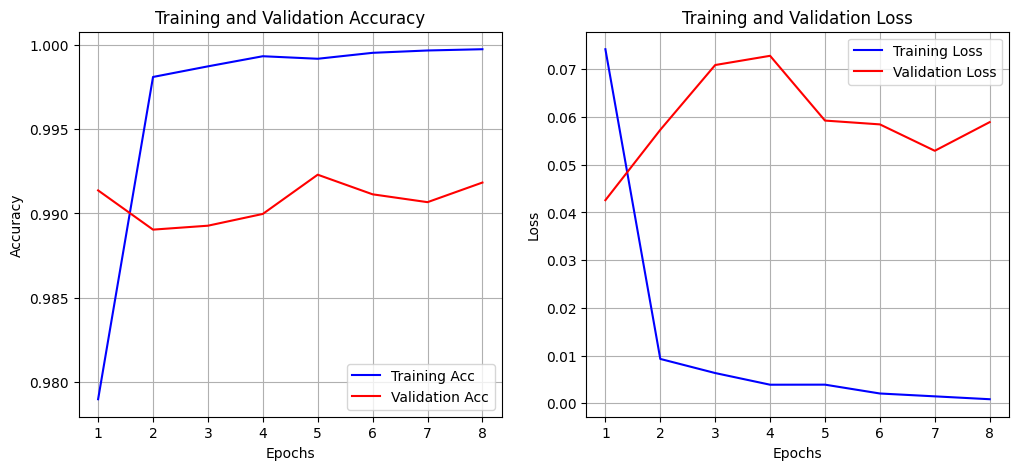

In [6]:
# Training loop

# Configuration
lr = 3e-4
num_epochs = 8
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=lr)
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

# Training
best_model, history = train_joint(
    model=model,
    train_syn_loader=train_syn_loader,
    train_real_loader=train_real_loader,
    val_loader=val_real_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=num_epochs,
    device=device,
    save_path=os.path.join(project_root, 'models/convnext_new_data_joint_v2.pth')
)

# Plotting train and validation statistics
plot_training_history(history)

## Evaluation

In [7]:
# Evaluation on real test data

test_real_dataset.return_fen = False
square_acc, board_acc = evaluate(best_model, test_real_loader, device)

print(f"Square accuracy: {square_acc:.2f}")
print(f"Board accuracy: {board_acc:.2f}")

Starting Evaluation on 204 boards...


Evaluating: 100%|██████████| 102/102 [00:12<00:00,  8.49it/s]

Square accuracy: 95.01
Board accuracy: 19.61


In [8]:
# Evaluation with solver on real test data

test_real_dataset.return_fen = False
square_acc, board_acc = evaluate_with_solver(best_model, test_real_loader, device)

print(f"Square accuracy: {square_acc:.2f}")
print(f"Board accuracy: {board_acc:.2f}")

Starting solver evaluation on 204 boards...


Solver Inference: 100%|██████████| 102/102 [00:23<00:00,  4.39it/s]

Square accuracy: 95.94
Board accuracy: 32.35
